In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, random_split, DataLoader, Subset
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
model = CNN(width=6, bn=True, normalise=False)
device = torch.device("mps")
results_dir = TRAINING_RESULTS / 'ext_high_mass' /'run_290626_164203'
weights_path = results_dir /'best_model_weights.pth'
#weights_path = results_dir / 'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=12288, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

In [3]:
DEVICE = torch.device("mps")
def accuracy(model, loader, threshold=0.5):
    model.eval()
    
    soft_correct, hard_correct, soft_total, hard_total = 0, 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            soft_correct += (predicted == labels).sum().item()
            hard_correct += ((predicted == labels).all(dim=1)).sum().item()
            soft_total += labels.numel()
            hard_total += labels.size(0)
    
    soft_acc = soft_correct/soft_total
    hard_acc = hard_correct/hard_total
    return soft_acc, hard_acc

In [4]:
training_ehm_dataset_path2 = TRAINING_DATASETS / 'training_ehm_dataset2.h5'
dataset = LISADataset(training_ehm_dataset_path)

unique_indices = np.unique(dataset.sim_indices)
all_indices = np.array(dataset.sim_indices)

rng = np.random.default_rng(42)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_sources = unique_indices[:n_train]
val_sources   = unique_indices[n_train:n_train+n_val]
test_sources  = unique_indices[n_train+n_val:]

train_indices = np.where(np.isin(all_indices, train_sources))[0]
val_indices   = np.where(np.isin(all_indices, val_sources))[0]
test_indices  = np.where(np.isin(all_indices, test_sources))[0]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

In [6]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1]

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(labels)

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)
probs = torch.cat(all_probs)

In [15]:
from sklearn.metrics import roc_curve, auc

probs = np.array(probs)
labels = np.array(labels)

fpr_gw, tpr_gw, _ = roc_curve(
    labels[:, 0],
    probs[:, 0]
)
fpr_glitch, tpr_glitch, _ = roc_curve(
    labels[:, 1],
    probs[:, 1]
)
auc_gw = auc(fpr_gw, tpr_gw)
auc_glitch = auc(fpr_glitch, tpr_glitch)

print("GW AUC =", auc_gw)
print("Glitch AUC =", auc_glitch)

np.savez(results_dir / 'roc_curves.npz',
         fpr_gw=fpr_gw,
        tpr_gw=tpr_gw,
        auc_gw=auc_gw,
        fpr_glitch=fpr_glitch,
        tpr_glitch=tpr_glitch,
        auc_glitch=auc_glitch)

GW AUC = 0.9993970000000001
Glitch AUC = 0.98066


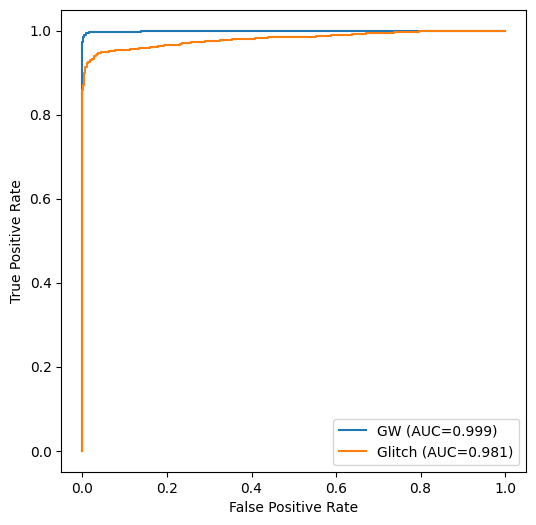

In [13]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr_gw,
    tpr_gw,
    label=f'GW (AUC={auc_gw:.3f})'
)

plt.plot(
    fpr_glitch,
    tpr_glitch,
    label=f'Glitch (AUC={auc_glitch:.3f})'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

In [219]:
train_loader = DataLoader(train_dataset, batch_size=64)
train_soft_acc, train_hard_acc = accuracy(model, train_loader)

val_loader = DataLoader(val_dataset, batch_size=64)
val_soft_acc, val_hard_acc = accuracy(model, val_loader)

test_loader = DataLoader(test_dataset, batch_size=64)
test_soft_acc, test_hard_acc = accuracy(model, test_loader)

print(f"Training Soft Accuracy: {train_soft_acc:.4f}, Training Hard Accuracy: {train_hard_acc:.4f}")
print(f"Validation Soft Accuracy: {val_soft_acc:.4f}, Validation Hard Accuracy: {val_hard_acc:.4f}")
print(f"Test Soft Accuracy: {test_soft_acc:.4f}, Test Hard Accuracy: {test_hard_acc:.4f}")

Training Soft Accuracy: 0.9911, Training Hard Accuracy: 0.9821
Validation Soft Accuracy: 0.9624, Validation Hard Accuracy: 0.9250
Test Soft Accuracy: 0.9525, Test Hard Accuracy: 0.9055


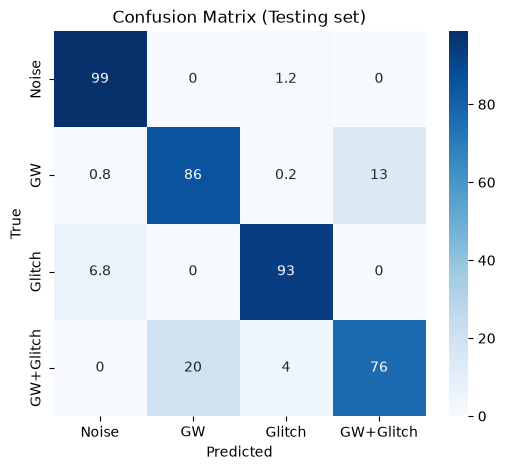

In [7]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class, normalize='true')*100
#np.savez(results_dir / 'confusion_matrix.npz', cm=cm)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [8]:
wrong = np.where((true_class == 3)&(pred_class == 1))[0]
wrong_sims = [test_dataset[i][2] for i in wrong]
wrong_times = np.array([test_dataset[i][3] for i in wrong])

right = np.where((true_class == 3)&(pred_class == 3))[0]
right_sims = np.array([test_dataset[i][2] for i in right])
right_times = np.array([test_dataset[i][3] for i in right])

In [9]:
np.savez(results_dir / 'mixed_results.npz', wrong_sims=wrong_sims,
         wrong_times=wrong_times, right_sims=right_sims, right_times=right_times)

In [10]:
def filter_mixed_dataset(mixed_dict, sims, times):
    filtered = {}
    filtered['QT'] = mixed_dict['QT'][sims, times, :, :, :]
    filtered['t_qscan'] = mixed_dict['t_qscan'][sims, times]
    filtered['f_qscan'] = mixed_dict['f_qscan'][sims, times]

    param_keys = ['X', 'Y', 'Z', 'amp', 'beta', 'd', 'gw_beta',\
                'gw_lambda', 'inj_point', 'm1', 'm2', 'sep', 'spin1',\
                'spin2', 'iota', 't0']
    for key in param_keys:
        filtered[key] = mixed_dict[key][sims]

    return filtered

In [11]:
mixed_dict = {}

mixed_ehm_dataset_path2 = MIXED_DATASETS / 'mixed_ehm_dataset2.h5'
with h5py.File(mixed_ehm_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        mixed_dict[key] = h5[key][:]

In [12]:
wrong_dict = filter_mixed_dataset(mixed_dict, wrong_sims, wrong_times)
right_dict = filter_mixed_dataset(mixed_dict, right_sims, right_times)

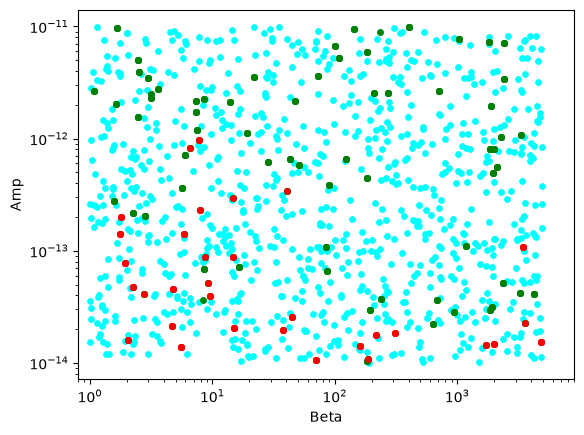

In [13]:
plt.scatter(mixed_dict['beta'], mixed_dict['amp'], s=15, color='cyan')
plt.scatter(right_dict['beta'], right_dict['amp'], s=15, color='green')
plt.scatter(wrong_dict['beta'], wrong_dict['amp'], s=15, color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.8, 9e3)
plt.xlabel('Beta')
plt.ylabel('Amp')
plt.show()

In [14]:
np.where(wrong_dict['sep'] > 1e-13)

(array([13, 14, 15, 16, 17, 18, 19, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34,
        35, 36, 37, 38, 39, 40, 41, 44, 45, 46, 47, 57, 58, 59, 60, 61, 62,
        63, 64, 65, 71, 72, 73, 74, 75, 76, 77, 78, 79]),)

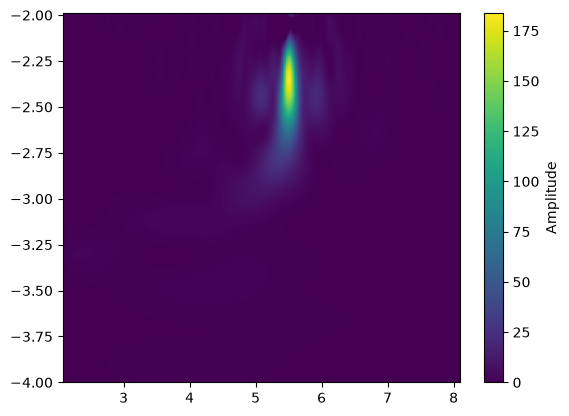

0.5027812


In [15]:
index = 24
image = wrong_dict['QT'][index,:,:,0]
t_axis = wrong_dict['t_qscan'][index]/3600
f_axis = wrong_dict['f_qscan'][index]

plt.imshow(image, extent=[t_axis[0], t_axis[-1], np.log10(f_axis[0]), np.log10(f_axis[-1])], aspect='auto', origin='lower')
plt.colorbar(label='Amplitude')
#plt.clim(0, 10)
plt.show()
print(wrong_dict['sep'][index])

In [25]:
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

wrong_dist = wrong_dict['d'] * u.Mpc
wrong_z = z_at_value(Planck18.luminosity_distance, wrong_dist)

right_dist = right_dict['d'] * u.Mpc
right_z = z_at_value(Planck18.luminosity_distance, right_dist)

all_dist = mixed_dict['d'] * u.Mpc
all_z = z_at_value(Planck18.luminosity_distance, all_dist)

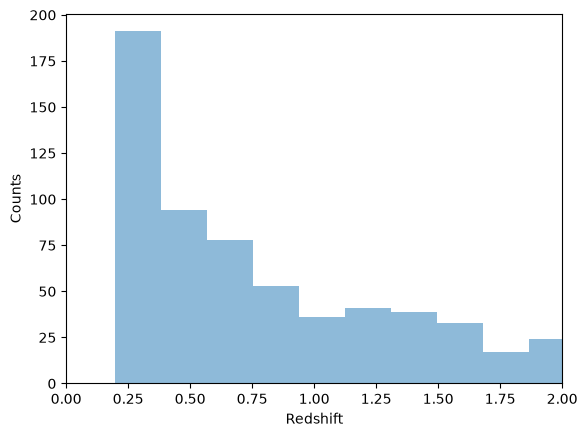

In [28]:
#plt.hist(wrong_z, bins=20, alpha=0.5)
#plt.hist(right_z, bins=20, alpha=0.5)
plt.hist(all_z, bins=50, alpha=0.5)
plt.xlabel('Redshift')
plt.ylabel('Counts')
plt.xlim(0, 2)
plt.show()

In [98]:
from helpers.simulation import *

orbits_path2 = str(DIST / 'orbits' / 'orbits2.h5')
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']
    
pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(10 * 3600 / 0.25),
        't_inj': 5 * 3600, 'keep_noises': ['test-mass', 'oms']}

gws = [{'type': 'BinaryInspiralGW', 'm1': wrong_dict['m1'][index], 'm2': wrong_dict['m2'][index],
         'd': wrong_dict['d'][index], 'iota':wrong_dict['iota'][index], 'spin1': wrong_dict['spin1'][index],
        'spin2': wrong_dict['spin2'][index], 't_inj': pipe['t_inj']+wrong_dict['sep'][index]*3600, 'domain': 'freq',
        'gw_beta':wrong_dict['gw_beta'][index], 'gw_lambda':wrong_dict['gw_lambda'][index]}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': pipe['t_inj']-wrong_dict['sep'][index]*3600,
              'beta': wrong_dict['beta'][index], 'level':2*wrong_dict['amp'][index]*wrong_dict['beta'][index],
                'inj_point':wrong_dict['inj_point'][index].decode('utf-8')}]

gws = [{'type': 'BinaryInspiralGW', 'm1': 5e6, 'm2': 5e6,
         'd': 1e3, 'iota':0, 'spin1': 0, 'spin2': 0, 't_inj': 5*3600, 'domain': 'freq',
        'gw_beta':0, 'gw_lambda':0}]

run_simulation(
            gws, glitches, pipe,
            gw_path, None, orbits_path,
            simulation_path,
            disable_noise=['test-mass', 'oms']
        )
raw_dict = run_tdi(simulation_path, pipe)

"""run_simulation(
            gws, glitches, pipe,
            None, glitch_path, orbits_path,
            simulation_path,
            disable_noise=['test-mass', 'oms']
        )
raw_dict2 = run_tdi(simulation_path, pipe)"""

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


"run_simulation(\n            gws, glitches, pipe,\n            None, glitch_path, orbits_path,\n            simulation_path,\n            disable_noise=['test-mass', 'oms']\n        )\nraw_dict2 = run_tdi(simulation_path, pipe)"

In [62]:
from scipy.interpolate import interp1d, RectBivariateSpline

def generate_ft_arr(frange, trange, Q):
    fmin, fmax = frange
    tmin, tmax = trange
    
    f=fmin
    f_arr = [fmin]
    while f <= fmax:
        f = f + (f/Q)*(2*np.sqrt(2))
        f_arr.append(f)
    
    t_arr = []
    for f in f_arr:
        t = tmin
        tslice = [tmin]
        while t <= tmax:
            t = t + (Q/f)*(1/(np.sqrt(2)*np.pi))
            tslice.append(t)
        t_arr.append(tslice)

    return f_arr, t_arr

def q_transform(times, signal, Q, frange, trange, resolution):
    
    f_arr, t_arr = generate_ft_arr(frange, trange, Q)

    QT = []
    for i, f in enumerate(f_arr):
        t_slice = t_arr[i]
        out_slice = []
        for t in t_slice:
            tau = Q/(np.sqrt(2)*np.pi*f)
            
            seg = np.where((times > t - 4*tau) & (times < t + 4*tau))[0]
            timeseg = times[seg]
            sigseg = signal[seg]
            sigseg = sigseg*np.hanning(len(sigseg))
            
            window = np.exp(-0.5 * ((timeseg-t)/tau)**2) * np.exp(-2j*np.pi*f*(timeseg-t))
            window /= np.sqrt(np.sum(np.abs(window)**2))
            out_slice.append(np.abs(np.sum(sigseg * window)))
        try:
            f = interp1d(t_slice, out_slice, kind='cubic', fill_value='extrapolate')
        except:
            f = interp1d(t_slice, out_slice, kind='linear', fill_value='extrapolate')
        QT.append(f(t_arr[-1]))

    QT = np.array(QT)
    QT /= np.median(QT, axis=1, keepdims=True)
    QT *= np.log(2)
    
    f_new = np.logspace(np.log10(np.min(f_arr)), np.log10(np.max(f_arr)), resolution, endpoint=True)
    t_new = np.linspace(np.min(t_arr[-1]), np.max(t_arr[-1]), resolution, endpoint=True)
    
    cubicspline = RectBivariateSpline(f_arr, t_arr[-1], QT, kx=3, ky=3)
    QTnew = cubicspline(f_new, t_new)
    QTnew = np.clip(QTnew, 1e-12, None)
    
    return t_new, f_new, QTnew

def generate_qscan(tdi_dict, channel, pipe, event, 
                   frange, trange, Q, resolution):

    signal = TimeSeries(tdi_dict[channel], dt=pipe['dt'], t0=0)
    
    time_secs = signal.times.value
    time_hrs = time_secs/3600
    tevent = event['t_inj']
    
    index = np.where((time_hrs <= tevent/3600 + trange[1]) & (time_hrs >= tevent/3600 + trange[0]))[0]
    sigslice = signal[index].value
    timeslice = signal[index].times.value
    
    t_arr, f_arr, QT = q_transform(timeslice, sigslice, Q=Q, resolution=resolution,
                        frange=frange, trange=(np.min(timeslice),np.max(timeslice)))

    return t_arr, f_arr, QT

In [99]:
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)
#tdi_dict2 = make_tdi_dict(raw_dict2['X'], raw_dict2['Y'], raw_dict2['Z'], whiten=True)

In [100]:
event = {'t_inj':5*3600}
res = 256
spec = SPECS['ext_high_mass']

QT_mixed = np.zeros((256, 256, 3))
for channel in ['A', 'E', 'T']:
    t_mixed, f_mixed, data = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=(1e-4, 1e-2), trange=(-3, 3), Q=6)
    QT_mixed[:, :, ['A', 'E', 'T'].index(channel)] = data


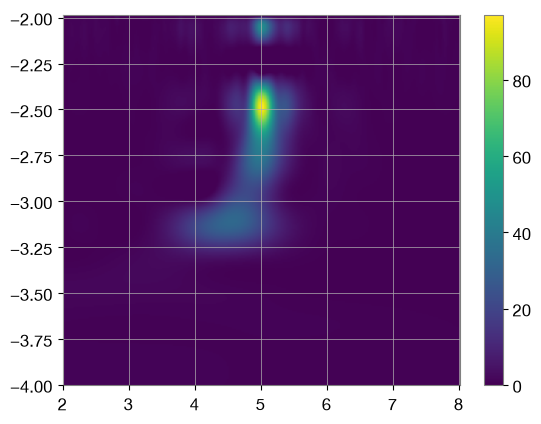

In [101]:
plt.imshow(QT_mixed[:, :, 0], extent=[t_mixed[0]/3600, t_mixed[-1]/3600, np.log10(f_mixed[0]), np.log10(f_mixed[-1])], aspect='auto', origin='lower')
plt.colorbar()
#plt.clim(0, 5)
plt.show()

In [46]:
mixed_dict2 = {}

with h5py.File(mixed_ehm_dataset_path2, 'r') as h5:
    for key in list(h5.keys()):
        mixed_dict2[key] = h5[key][:]

In [104]:
mixed_dict = {}

mixed_ehm_dataset_path3 = MIXED_DATASETS / 'mixed_ehm_dataset3.h5'
with h5py.File(mixed_ehm_dataset_path3, 'r') as h5:
    for key in list(h5.keys()):
        mixed_dict[key] = h5[key][:]

In [105]:
t = np.arange(0, 10*3600, 0.25)/3600
channel = 'A'
snr_ratios = []
for index in range(1000):
    tdi_dict = make_tdi_dict(mixed_dict['X'][index], mixed_dict['Y'][index],\
                          mixed_dict['Z'][index], whiten=True)
    if mixed_dict['sep'][index] >= 0:
        gw_snr = np.max(np.abs(tdi_dict[channel][t >= 5]))
        glitch_snr = np.max(np.abs(tdi_dict[channel][t < 5]))
        snr_ratios.append(gw_snr/glitch_snr)
    else:
        gw_snr = np.max(np.abs(tdi_dict[channel][t < 5]))
        glitch_snr = np.max(np.abs(tdi_dict[channel][t >= 5]))
        snr_ratios.append(gw_snr/glitch_snr)

In [93]:
t = np.arange(0, 10*3600, 0.25)/3600
channel = 'A'
snr_ratios2 = []
for index in range(1000):
    tdi_dict = make_tdi_dict(mixed_dict2['X'][index], mixed_dict2['Y'][index],\
                          mixed_dict2['Z'][index], whiten=True)
    if mixed_dict['sep'][index] >= 0:
        gw_snr = np.max(np.abs(tdi_dict[channel][t >= 5]))
        glitch_snr = np.max(np.abs(tdi_dict[channel][t < 5]))
        snr_ratios2.append(gw_snr/glitch_snr)
    else:
        gw_snr = np.max(np.abs(tdi_dict[channel][t < 5]))
        glitch_snr = np.max(np.abs(tdi_dict[channel][t >= 5]))
        snr_ratios2.append(gw_snr/glitch_snr)

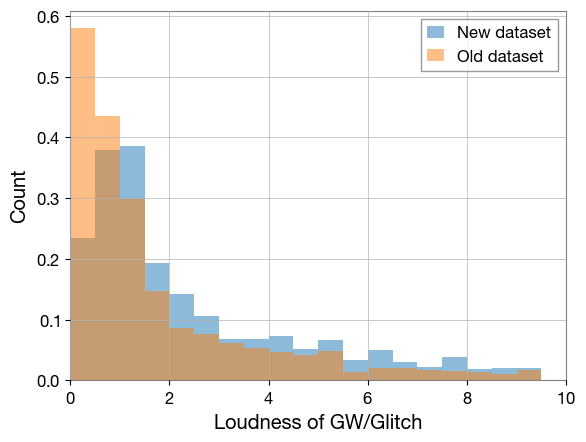

In [111]:
bins = np.arange(0, 10, 0.5)

plt.hist(snr_ratios, bins=bins, label='New dataset', alpha=0.5, density=True)
plt.hist(snr_ratios2, bins=bins, label='Old dataset', alpha=0.5, density=True)
plt.ylabel('Count')
plt.xlabel('Loudness of GW/Glitch')
#plt.yscale('log')
plt.xlim(0, 10)
plt.legend()
plt.show()

In [12]:
mixed_dict = {}

mixed_ehm_old_path = MIXED_DATASETS / 'mixed_gwbeta_way.h5'
with h5py.File(mixed_ehm_old_path, 'r') as h5:
    for key in list(h5.keys()):
        mixed_dict[key] = h5[key][:]

In [13]:
from helpers.simulation import *

t = np.arange(0, 10*3600, 0.25)/3600
channel = 'A'
snr_ratios = []
for index in range(100):
    tdi_dict = make_tdi_dict(mixed_dict['X'][index], mixed_dict['Y'][index],\
                          mixed_dict['Z'][index], whiten=True)
    if mixed_dict['sep'][index] >= 0:
        gw_snr = np.max(np.abs(tdi_dict[channel][t >= 5]))
        glitch_snr = np.max(np.abs(tdi_dict[channel][t < 5]))
        snr_ratios.append(gw_snr/glitch_snr)
    else:
        gw_snr = np.max(np.abs(tdi_dict[channel][t < 5]))
        glitch_snr = np.max(np.abs(tdi_dict[channel][t >= 5]))
        snr_ratios.append(gw_snr/glitch_snr)

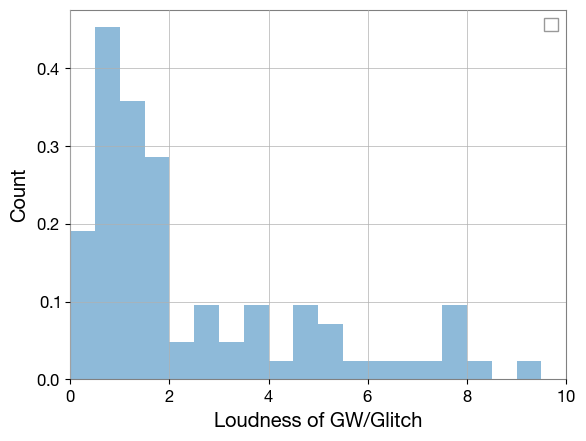

In [14]:
bins = np.arange(0, 10, 0.5)

plt.hist(snr_ratios, bins=bins, alpha=0.5, density=True)
plt.ylabel('Count')
plt.xlabel('Loudness of GW/Glitch')
#plt.yscale('log')
plt.xlim(0, 10)
plt.legend()
plt.show()

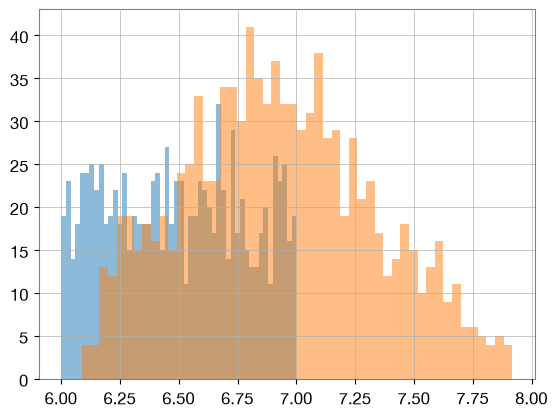

In [33]:
from helpers.simulation import *

z = z_at_value(Planck18.luminosity_distance, mixed_dict['d']*u.Mpc)

m1_d = mixed_dict['m1']*(1+z)
m2_d = mixed_dict['m2']*(1+z)

chirp = chirp_mass(mixed_dict['m1'], mixed_dict['m2'])
chirp_d = chirp_mass(m1_d, m2_d)

plt.hist(np.log10(chirp), bins=50, alpha=0.5)
plt.hist(np.log10(chirp_d), bins=50, alpha=0.5)
plt.show()

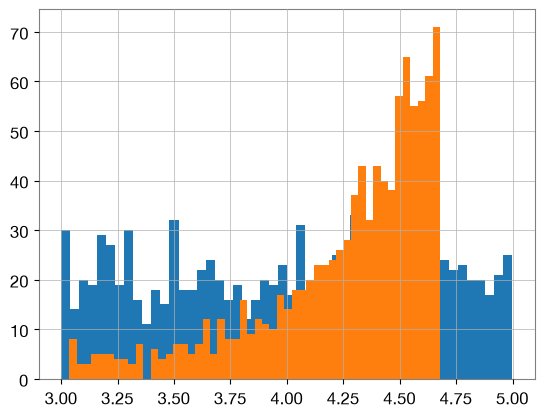

In [46]:
z_arr = np.random.uniform(0.2, 5, size=1000)
Dl = Planck18.luminosity_distance(z_arr)

plt.hist(np.log10(mixed_dict['d']), bins=50)
plt.hist(np.log10(Dl.value), bins=50)
plt.show()

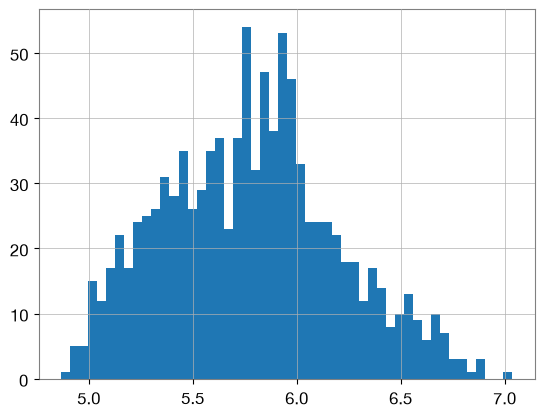

In [102]:
z_arr = np.random.uniform(0.5, 5, size=1000)
d_arr = Planck18.luminosity_distance(z_arr).value

Mc_array = 10**np.random.uniform(5, 6, size=1000)
q_array = np.random.uniform(1, 5, size=1000)

m1_arr = Mc_array * ((1 + q_array)**(1/5) / q_array**(3/5)) * (1+z)
m2_arr = m1_arr * q_array

plt.hist(np.log10(m1_arr), bins=50)
plt.show()